# Norman 2019 — Fig 1 Panel_a: TF community graph

Builds and plots the TF-TF regulatory network coloured by community assignment.

**Input files** (under `data/real/Norman2019/GRN/`)
- `raw_GRN.csv` — raw GRN edge list with coefficients and p-values
- `tf_communities_{pct}pct_gamma{gamma}.csv` — TF community assignments

**Output files** (under `results/figures/main/Fig1/Norman2019/Panel_a/`)
- `clustered_graph.png` / `.svg` — community-coloured TF-TF graph

In [1]:
import os
import random
import numpy as np
import pandas as pd
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import false_discovery_control

In [2]:
# ── Control panel ─────────────────────────────────────────────
pct              = 40
gamma            = '1p1'
significance_level = 0.05
top_percentage   = 1.0         # fraction of top-ranked TF-TF edges to retain in the plot
seed             = 50

grn_folder   = '../../../../data/real/Norman2019/GRN/'
raw_grn_file = grn_folder + 'raw_GRN.csv'
nodes_file   = grn_folder + f'tf_communities_{pct}pct_gamma{gamma}.csv'
res_folder   = './Norman2019/Panel_a'

# community colours — same order as all other panels
custom_colors = ['yellow', 'darkmagenta', 'cyan', 'red3', 'green3', 'blue3', 'violet', 'orange']

os.makedirs(res_folder, exist_ok=True)

In [3]:
# Load node community assignments
nodes_df = pd.read_csv(nodes_file)
print(nodes_df.groupby('community').size().rename('n_tfs'))
nodes_df.head()

community
0    28
1    30
2    23
3    17
4    18
5    12
6     2
8    11
Name: n_tfs, dtype: int64


,community,tf
0,0,AHR
1,0,BATF3
2,0,BHLHE41
3,0,BPTF
4,0,CEBPA


In [4]:
# Load raw GRN, apply FDR filter, keep TF-TF edges only, take top_percentage
raw_grn = pd.read_csv(raw_grn_file, index_col=0).dropna(subset=['p'])
raw_grn['adjp'] = false_discovery_control(raw_grn['p'].values, method='bh')
filtered_grn = raw_grn[raw_grn['adjp'] <= significance_level].sort_values('coef_abs', ascending=False)

tfs = set(nodes_df['tf'])
tf_tf_grn = filtered_grn[(filtered_grn['source'].isin(tfs)) & (filtered_grn['target'].isin(tfs))].copy()

n_top = max(1, int(len(tf_tf_grn) * top_percentage))
edges_df = tf_tf_grn.iloc[:n_top].reset_index(drop=True)
edges_df = edges_df.rename(columns={'coef_abs': 'weight'})[['source', 'target', 'weight']]

# Add community labels to edge table
comm_map = dict(zip(nodes_df['tf'], nodes_df['community']))
edges_df['community'] = edges_df['source'].map(comm_map)

print(f'TF-TF edges retained: {len(edges_df)}')
edges_df.head()

TF-TF edges retained: 4619


,source,target,weight,community
0,MLXIP,ENO1,0.266650,0
1,LYL1,YBX1,0.174611,5
2,HOXB4,LYL1,0.170987,5
3,PITX1,LMO2,0.157015,3
4,NFE2,PITX1,0.142877,3


In [5]:
# Build igraph
random.seed(seed)
np.random.seed(seed)

edges = list(zip(edges_df['source'], edges_df['target']))
ig_graph = ig.Graph.TupleList(edges, directed=True)
ig_graph.es['weight'] = edges_df['weight'].tolist()

name_to_cluster = dict(zip(nodes_df['tf'], nodes_df['community']))
ig_graph.vs['cluster'] = [name_to_cluster.get(name, -1) for name in ig_graph.vs['name']]

cluster_ids = sorted(set(name_to_cluster.values()))

# Build per-cluster subgraphs and FR layouts
clusters, layouts, bboxes = [], [], []
for cluster_id in cluster_ids:
    node_indices = [v.index for v in ig_graph.vs if v['cluster'] == cluster_id]
    g_sub = ig_graph.subgraph(node_indices)
    clusters.append(g_sub)
    layout_np = np.array(g_sub.layout('fr')) * 2.0
    layouts.append(layout_np)
    mn, mx = layout_np.min(axis=0), layout_np.max(axis=0)
    bboxes.append((mx[0] - mn[0], mx[1] - mn[1]))

# Grid placement
grid_cols = int(np.ceil(np.sqrt(len(clusters))))
padding = 5
global_layout = [None] * ig_graph.vcount()
for i, (cluster_id, g_sub, layout_np, (w, h)) in enumerate(zip(cluster_ids, clusters, layouts, bboxes)):
    row, col = i // grid_cols, i % grid_cols
    x_off, y_off = col * (w + padding), row * (h + padding)
    for j, (x, y) in enumerate(layout_np):
        node_name = g_sub.vs[j]['name']
        global_layout[ig_graph.vs.find(name=node_name).index] = (x + x_off, y + y_off)

# Node colours by community (consistent palette)
cluster_id_to_color = {cid: custom_colors[i] for i, cid in enumerate(cluster_ids)}
ig_graph.vs['color'] = [cluster_id_to_color[name_to_cluster[name]] for name in ig_graph.vs['name']]

# Edge opacity by weight
weights = np.array(ig_graph.es['weight'])
w_norm = (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)
def rgba_gray(alpha):
    return f'#888888{int(alpha * 255):02X}'
#ig_graph.es['color'] = [rgba_gray(0.3 + 0.7 * a) for a in w_norm]
ig_graph.es['color'] = [rgba_gray(0.2 * a) for a in w_norm]

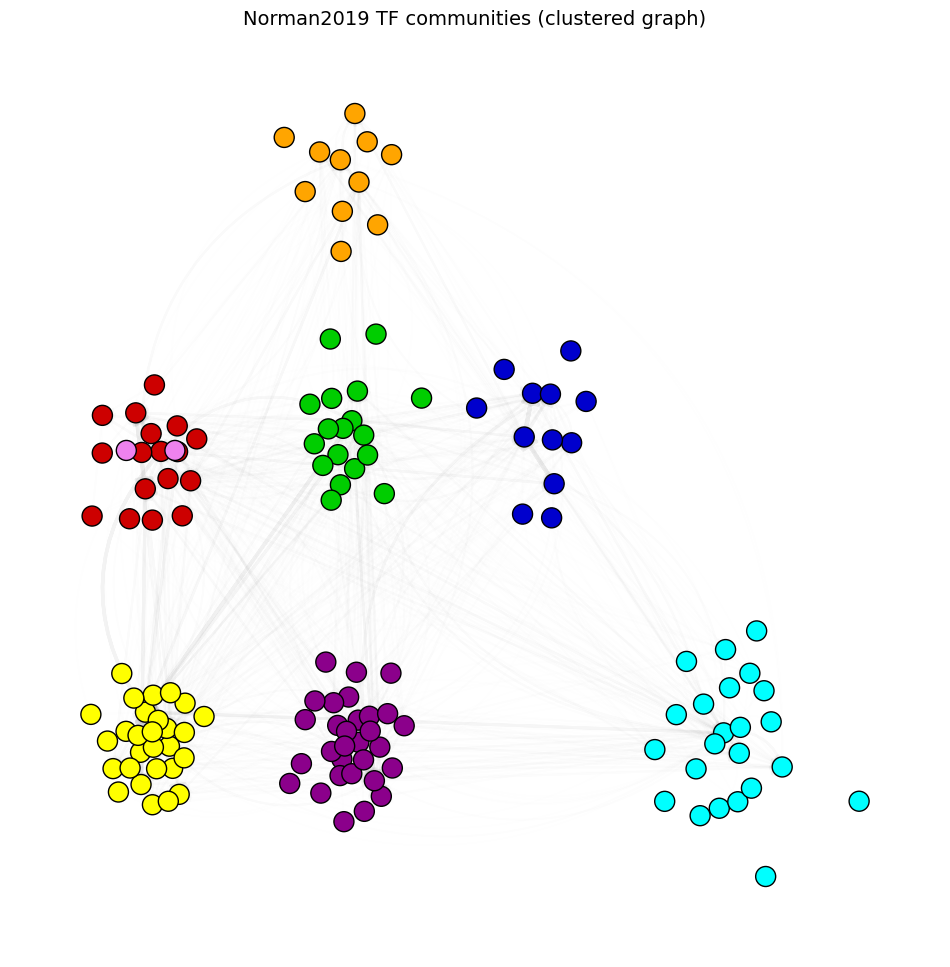

Saved to ./Norman2019/Panel_a


In [6]:
fig, ax = plt.subplots(figsize=(12, 12))
ig.plot(
    ig_graph,
    layout=global_layout,
    target=ax,
    vertex_size=20,
    vertex_label=None,
    vertex_frame_color=None,
    vertex_shape='circle',
    edge_arrow_size=0.4,
    edge_width=[1 + 3 * w for w in w_norm],
    bbox=(800, 800),
    margin=40,
)
plt.title('Norman2019 TF communities (clustered graph)', fontsize=14)

plt.savefig(os.path.join(res_folder, 'clustered_graph.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(res_folder, 'clustered_graph.svg'), format='svg', bbox_inches='tight')
plt.show()
print('Saved to', res_folder)

In [7]:
# Sanity checks: inter-community edges and isolated nodes
inter_pairs = set()
for edge in ig_graph.es:
    c1 = ig_graph.vs[edge.source]['cluster']
    c2 = ig_graph.vs[edge.target]['cluster']
    if c1 != c2:
        inter_pairs.add(tuple(sorted((c1, c2))))
print(f'{len(inter_pairs)} community pairs have inter-community edges.')

isolated = [
    v['name'] for v in ig_graph.vs
    if not any(ig_graph.vs[n]['cluster'] == v['cluster'] for n in ig_graph.neighbors(v.index, mode='all'))
]
print(f'{len(isolated)} node(s) isolated within their own community.')

28 community pairs have inter-community edges.
2 node(s) isolated within their own community.
